In [33]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd
import time

S0 = 100
K  = 100
r = 0.03
sigma = 0.2
T = 1
SEED = 42

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    
    return price

V_BS = black_scholes_call(S0, K, r, sigma, T)

print(f"Black-Scholes benchmark: {V_BS:.4f}")

Black-Scholes benchmark: 9.4134


In [34]:
def generate_iid_variables(M):
    return rng.standard_normal(M)

def S_T(S0, r, sigma, T, Z):
    exponent = (r - 0.5*sigma**2) * T + sigma * np.sqrt(T)*Z
    return S0*np.exp(exponent)

def payoff_function(S, K):
    return np.maximum(S - K, 0)

def V_hat(payoff, M, r, T):
    return np.exp(-r * T) / M * np.sum(payoff)

def SE_hat(payoff, M, r, T):
    sample_std = np.std(payoff, ddof = 1)
    return np.exp(-r * T) * sample_std / np.sqrt(M)



In [35]:
rng = np.random.default_rng(SEED)

M_values = np.array([10**2, 5*10**2, 10**3, 5*10**3, 10**4, 5*10**4, 10**5, 5*10**5])
R = 100
mean_V = np.zeros(len(M_values))
mean_SE = np.zeros(len(M_values))

RMSE = np.zeros(len(M_values))
empirical_coverages = np.zeros(len(M_values))
CI_upper = np.zeros(len(M_values))
CI_lower = np.zeros(len(M_values))
representative_V = np.zeros(len(M_values))

for i, M in enumerate(M_values):
    V_estimates = np.zeros(R)
    SE_estimates = np.zeros(R)
    CI_upper_estimates = np.zeros(R)
    CI_lower_estimates = np.zeros(R)
    covered = np.zeros(R)

    for j in range(R):
        Z = generate_iid_variables(M)

        ST = S_T(S0, r, sigma, T, Z)

        payoff = payoff_function(ST, K)

        V_estimates[j] = V_hat(payoff, M, r, T)
        SE_estimates[j] = SE_hat(payoff, M, r, T)
        CI_upper_estimates[j] = V_estimates[j] + 1.96 * SE_estimates[j]
        CI_lower_estimates[j] = V_estimates[j] - 1.96 * SE_estimates[j]
        if CI_lower_estimates[j] <= V_BS <= CI_upper_estimates[j]:
            covered[j] = 1
        else:
            covered[j] = 0
    RMSE[i] = np.sqrt(1/R * np.sum((V_estimates - V_BS)**2))
    empirical_coverages[i] = np.mean(covered)  
    CI_upper[i] = CI_upper_estimates[0]
    CI_lower[i] = CI_lower_estimates[0]
    representative_V[i] = V_estimates[0]
    mean_V[i] = np.mean(V_estimates)
    mean_SE[i] = np.mean(SE_estimates)


In [36]:
coverage_se = np.sqrt(0.95 * 0.05 / R)

results = pd.DataFrame({
    "M": M_values,
    "Mean estimate": mean_V,
    "Mean SE": mean_SE,
    "RMSE": RMSE,
    "Bias":mean_V - V_BS,
    "Coverage": empirical_coverages,
})

print(f"Table 1: Standard Monte Carlo convergence, "
      f"S0={S0}, K ={K}, r={r}, sigma={sigma}, T={T}; "
      f"R = {R} replications per M; seed = {SEED}; V_BS = {V_BS:.4f}")
print(f"(Monte Carlo SE of the coverage estimate at nominal 0.95 with R = {R}: {coverage_se:.3f})")
print(results.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))

Table 1: Standard Monte Carlo convergence, S0=100, K =100, r=0.03, sigma=0.2, T=1; R = 100 replications per M; seed = 42; V_BS = 9.4134
(Monte Carlo SE of the coverage estimate at nominal 0.95 with R = 100: 0.022)
     M  Mean estimate   Mean SE      RMSE      Bias  Coverage
   100         9.3130    1.4086    1.4424   -0.1004    0.9200
   500         9.4229    0.6338    0.7178    0.0095    0.9100
  1000         9.4100    0.4485    0.3967   -0.0034    0.9900
  5000         9.3978    0.1993    0.2160   -0.0156    0.9200
 10000         9.4351    0.1413    0.1293    0.0217    0.9700
 50000         9.4159    0.0631    0.0591    0.0025    0.9700
100000         9.4043    0.0446    0.0430   -0.0091    0.9600
500000         9.4169    0.0200    0.0202    0.0035    0.9700


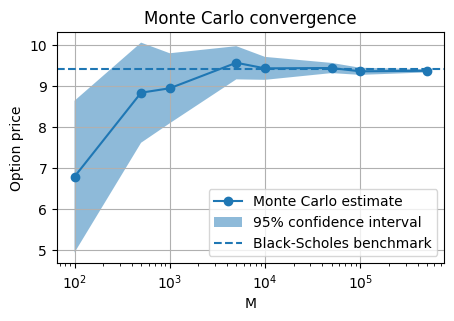

In [37]:
plt.figure(figsize=(5, 3))

plt.plot(M_values, representative_V, 'o-', label='Monte Carlo estimate')

plt.fill_between(
    M_values,
    CI_lower,
    CI_upper,
    alpha=0.5,
    label='95% confidence interval'
)

plt.axhline(V_BS, linestyle='--', label='Black-Scholes benchmark')
plt.xscale('log')
plt.xlabel('M')
plt.ylabel('Option price')
plt.title('Monte Carlo convergence')
plt.legend()
plt.grid()
plt.show()

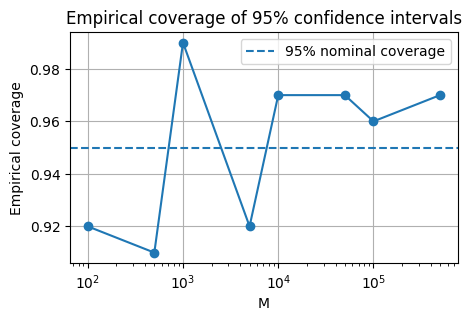

In [38]:
plt.figure(figsize=(5, 3))

plt.plot(M_values, empirical_coverages, 'o-')
plt.axhline(0.95, linestyle='--', label='95% nominal coverage')

plt.xscale('log')
plt.xlabel('M')
plt.ylabel('Empirical coverage')
plt.title('Empirical coverage of 95% confidence intervals')
plt.legend()
plt.grid()

plt.show()

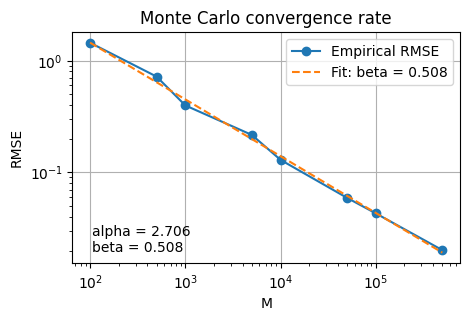

In [39]:
slope, intercept = np.polyfit(np.log(M_values), np.log(RMSE), 1)

beta = -slope
a = intercept

# Fitted RMSE values
RMSE_fit = np.exp(a) * M_values**(-beta)

plt.figure(figsize=(5, 3))

plt.loglog(M_values, RMSE, 'o-', label='Empirical RMSE')
plt.loglog(M_values, RMSE_fit, '--', label=f'Fit: beta = {beta:.3f}')

plt.xlabel('M')
plt.ylabel('RMSE')
plt.title('Monte Carlo convergence rate')

plt.text(0.05, 0.05, f'alpha = {a:.3f}\nbeta = {beta:.3f}', transform=plt.gca().transAxes)

plt.legend()
plt.grid()
plt.show()

### Antithetic estimator

In [40]:
def antithetic_pair_averages(M):
    Z = generate_iid_variables(M)
    payoff_plus = payoff_function(S_T(S0, r, sigma, T, Z), K)
    payoff_minus = payoff_function(S_T(S0, r, sigma, T, -Z), K)
    return 0.5 * (payoff_plus + payoff_minus)

def V_hat_antithetic(Y, M, r, T):
    return np.exp(-r * T) / M * np.sum(Y)

def SE_hat_antithetic(Y, M, r, T):
    return np.exp(-r * T) * np.std(Y, ddof = 1) / np.sqrt(M)

### Equal-cost comparison

In [41]:
rng = np.random.default_rng(SEED)

M_av = np.array([10**2, 10**3, 10**4, 10**5])
R_av = 100

var_standard   = np.zeros(len(M_av))
var_antithetic  = np.zeros(len(M_av))
mean_standard   = np.zeros(len(M_av))
mean_antithetic = np.zeros(len(M_av))

for i, M in enumerate(M_av):
    V_std = np.zeros(R_av)
    V_ant = np.zeros(R_av)

    for j in range(R_av):
        Z = generate_iid_variables(2*M)
        payoff = payoff_function(S_T(S0, r, sigma, T, Z), K)
        V_std[j] = V_hat(payoff, 2*M, r, T)

        Y = antithetic_pair_averages(M)
        V_ant[j] = V_hat_antithetic(Y, M, r, T)

    var_standard[i] = np.var(V_std, ddof = 1)
    var_antithetic[i] = np.var(V_ant, ddof = 1)
    mean_standard[i] = np.mean(V_std)
    mean_antithetic[i] = np.mean(V_ant)

VRF = var_standard/ var_antithetic








### VRF table

Table 2: Standard vs antithetic at equal cost (2M payoff evaluations each). R=100 repetitions; seed=42; V_BS=9.4134.
 M (pairs)  Evaluations  Mean standard  Mean antithetic  Var standard  Var antithetic          VRF
       100          200         9.5901           9.4833        1.1895         0.50102       2.3743
      1000         2000         9.3899           9.4347        0.1002        0.066103       1.5159
     10000        20000         9.4302           9.4036     0.0076481       0.0045785       1.6704
    100000       200000         9.4101           9.4115      0.001079      0.00047355       2.2785

Mean variance-reduction factor: 1.96


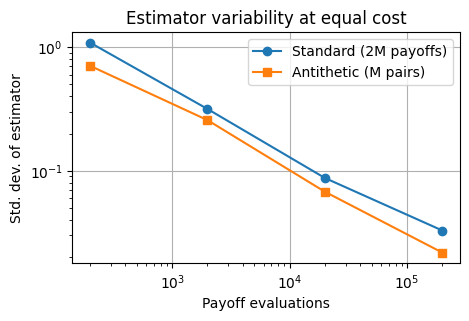

In [42]:
av_results = pd.DataFrame({
    "M (pairs)": M_av,
    "Evaluations": 2*M_av,
    "Mean standard": mean_standard,
    "Mean antithetic": mean_antithetic,
    "Var standard": var_standard,
    "Var antithetic": var_antithetic,
    "VRF": VRF,
})
print(f"Table 2: Standard vs antithetic at equal cost (2M payoff evaluations each). "
      f"R={R_av} repetitions; seed={SEED}; V_BS={V_BS:.4f}.")
print(av_results.to_string(index=False, float_format=lambda x: f"{x:12.5g}"))
print(f"\nMean variance-reduction factor: {VRF.mean():.2f}")
 
plt.figure(figsize=(5, 3))
plt.loglog(2*M_av, np.sqrt(var_standard),   'o-', label='Standard (2M payoffs)')
plt.loglog(2*M_av, np.sqrt(var_antithetic), 's-', label='Antithetic (M pairs)')
plt.xlabel('Payoff evaluations')
plt.ylabel('Std. dev. of estimator')
plt.title('Estimator variability at equal cost')
plt.legend()
plt.grid()
plt.show()

### Theoretical VRF
VRF = Var(h)/(2 Var(y)) = 1/(1+rho), rho = Corr(h(Z)), h=(-Z)

In [43]:
Z_big = rng.standard_normal(10**7)
h_plus  = payoff_function(S_T(S0, r, sigma, T,  Z_big), K)
h_minus = payoff_function(S_T(S0, r, sigma, T, -Z_big), K)
rho = np.corrcoef(h_plus, h_minus)[0, 1]
 
print(f"Corr(h(Z), h(-Z)) = {rho:.4f}")
print(f"Theoretical VRF   = 1/(1+rho) = {1/(1+rho):.3f}")

Corr(h(Z), h(-Z)) = -0.4447
Theoretical VRF   = 1/(1+rho) = 1.801


### Timing

In [ ]:
import timeit

M_timing = 10**6
rng = np.random.default_rng(SEED)

def run_standard():
    p = payoff_function(S_T(S0, r, sigma, T, generate_iid_variables(2*M_timing)), K)
    return V_hat(p, 2*M_timing, r, T)

def run_antithetic():
    Y = antithetic_pair_averages(M_timing)
    return V_hat_antithetic(Y, M_timing, r, T)

run_standard(); run_antithetic()         

n_rep, n_loop = 7, 3
t_std = min(timeit.repeat(run_standard,   repeat=n_rep, number=n_loop)) / n_loop
t_ant = min(timeit.repeat(run_antithetic, repeat=n_rep, number=n_loop)) / n_loop

print(f"Best of {n_rep} x {n_loop} runs at {2*M_timing:,} payoff evaluations:")
print(f"  standard   : {t_std*1000:7.1f} ms")
print(f"  antithetic : {t_ant*1000:7.1f} ms")
print(f"  ratio (standard / antithetic): {t_std/t_ant:.2f}")

Best of 7 x 3 runs at 2,000,000 payoff evaluations:
  standard   :    45.0 ms
  antithetic :    27.4 ms
  ratio (standard / antithetic): 1.65
